# Finland Electricity Demand Forecasting - ML Pipeline

Predicting electricity demand gap (production - demand) for the next 1-12 hours.

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import warnings
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings('ignore')
dir = os.getcwd()
DATA_DIR = Path("/Users/armandhubler/Documents/coding_project/hackeurope26/ml/data/fin")
WEATHER_PATH = Path("/Users/armandhubler/Documents/coding_project/hackeurope26/ml/data/weather-data/finland_helsinki_2016-02-21_2026-02-21_hourly.csv")
OUTPUT_DIR = Path("/Users/armandhubler/Documents/coding_project/hackeurope26/ml/fin")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data Loading

In [2]:
demand_df = pd.read_excel(DATA_DIR / "demand.xlsx")
production_df = pd.read_excel(DATA_DIR / "production.xlsx")
solar_df = pd.read_excel(DATA_DIR / "solar.xlsx")
wind_df = pd.read_excel(DATA_DIR / "wind.xlsx")
weather_df = pd.read_csv(WEATHER_PATH)

weather_df = weather_df[weather_df['country_code'] == 'FI'].copy()

print("Data loaded successfully")
print(f"Demand: {demand_df.shape}, Production: {production_df.shape}")
print(f"Solar: {solar_df.shape}, Wind: {wind_df.shape}")
print(f"Weather: {weather_df.shape}")

Data loaded successfully
Demand: (123038, 3), Production: (123073, 3)
Solar: (124356, 3), Wind: (123037, 3)
Weather: (87696, 14)


## 2. Data Preprocessing

In [3]:
demand_df = demand_df.groupby("startTime")['Electricity consumption in Finland'].sum()
production_df = production_df.groupby("startTime")['Electricity production in Finland'].sum()
solar_df = solar_df.groupby("startTime")['Solar power generation forecast - updated every 15 minutes'].sum()
wind_df = wind_df.groupby("startTime")['Wind power generation - 15 min data'].sum()

demand_df = demand_df.rename("demand")
production_df = production_df.rename("overall_production")
solar_df = solar_df.rename("solar_production")
wind_df = wind_df.rename("wind_production")

for df in [demand_df, production_df, solar_df, wind_df]:
    df.index = pd.to_datetime(df.index)
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    else:
        df.index = df.index.tz_convert("UTC")

In [4]:
weather_df.rename(columns={"time": "datetime"}, inplace=True)
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])
weather_df.set_index("datetime", inplace=True)
weather_df.index = weather_df.index.tz_localize("UTC")
weather_df.drop(columns=["country", "country_code", "location", "timezone", "latitude_used", "longitude_used"], inplace=True)

In [5]:
df = pd.concat([demand_df, production_df, solar_df, wind_df], axis=1).sort_index()
df = df.merge(weather_df, left_index=True, right_index=True, how="left")
df = df[df.index.minute == 0]

print(f"Merged shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Merged shape: (52616, 11)
Date range: 2020-02-20 23:00:00+00:00 to 2026-02-20 22:00:00+00:00


In [6]:
nan_pct = df.isna().mean() * 100
print("Missing values (%):")
print(nan_pct[nan_pct > 0])

df.dropna(inplace=True)
print(f"\nAfter dropping NaN: {df.shape}")

Missing values (%):
demand                  0.070321
overall_production      0.053216
solar_production        0.015205
wind_production         0.066520
temperature_2m          0.237570
relative_humidity_2m    0.237570
precipitation           0.237570
wind_speed_10m          0.237570
wind_direction_10m      0.237570
surface_pressure        0.237570
cloud_cover             0.237570
dtype: float64

After dropping NaN: (52453, 11)


## 3. Feature Engineering

In [7]:
df['Gap'] = df['overall_production'] - df['demand']
df['fossil_production'] = df['overall_production'] - df['solar_production'] - df['wind_production']

for h in range(1, 13):
    df[f'Gap_t_plus_{h}h'] = df['Gap'].shift(-h)

In [8]:
lag_cols = ['Gap', 'demand', 'overall_production', 'solar_production', 'wind_production', 'temperature_2m', 'wind_speed_10m']

new_cols = {}
for col in lag_cols:
    for l in [1, 2, 3, 6, 12, 24]:
        new_cols[f"{col}_lag_{l}"] = df[col].shift(l)
    for w in [6, 12, 24]:
        new_cols[f"{col}_roll_mean_{w}"] = df[col].rolling(w).mean()
        new_cols[f"{col}_roll_std_{w}"] = df[col].rolling(w).std()

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

In [9]:
df["hour"] = df.index.hour
df["dow"] = df.index.dayofweek
df["month"] = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [10]:
df["demand_hour_mean"] = df.groupby("hour")["demand"].transform("mean")
df["demand_dow_mean"] = df.groupby("dow")["demand"].transform("mean")
df["demand_surprise"] = df["demand"] - df["demand_hour_mean"]

df["wind_hour_mean"] = df.groupby("hour")["wind_production"].transform("mean")
df["wind_surprise"] = df["wind_production"] - df["wind_hour_mean"]

df.dropna(inplace=True)
print(f"Final dataset: {df.shape}")

Final dataset: (52417, 123)


## 4. Exploratory Data Analysis

In [11]:
print("Target Variable Statistics (Gap - MW):")
print(df['Gap'].describe())

Target Variable Statistics (Gap - MW):
count    52417.000000
mean     -1035.316023
std       1155.770385
min      -4619.000000
25%      -1856.000000
50%      -1249.000000
75%       -307.620000
max       3395.550000
Name: Gap, dtype: float64


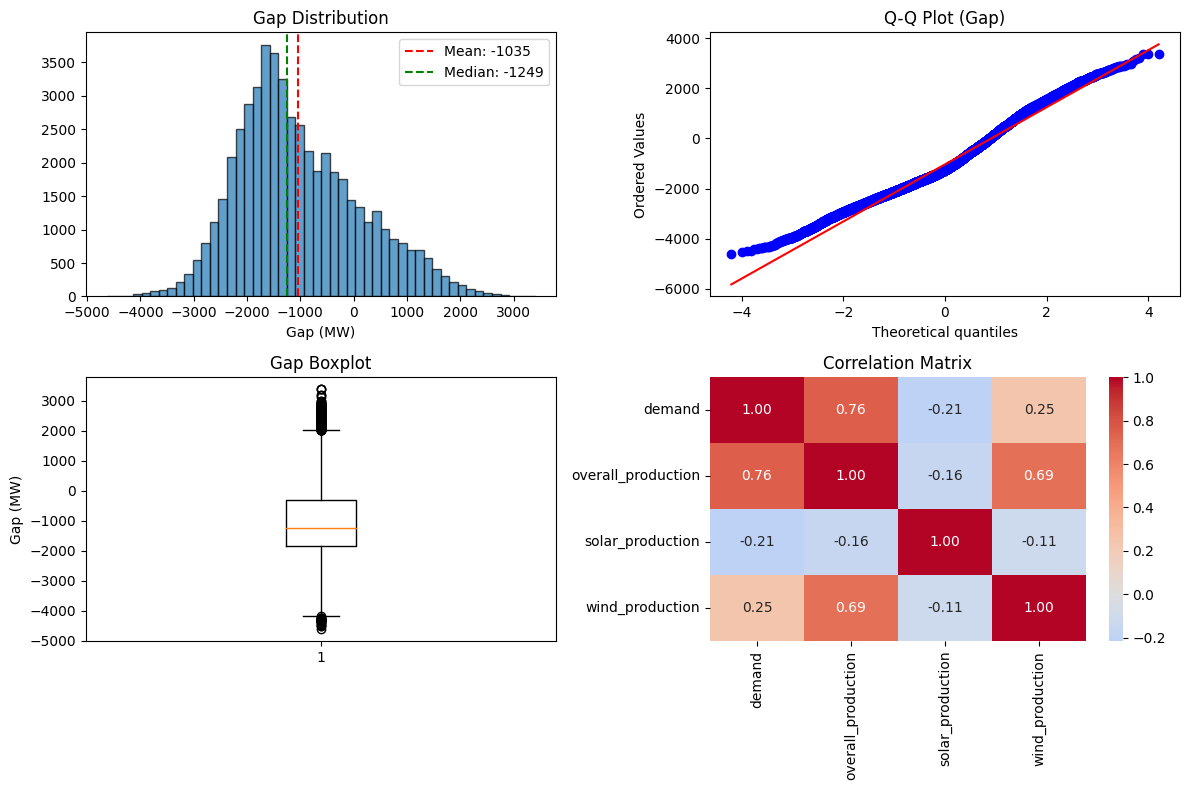


Skewness: 0.539
Kurtosis: -0.035


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df['Gap'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Gap Distribution')
axes[0, 0].set_xlabel('Gap (MW)')
axes[0, 0].axvline(df['Gap'].mean(), color='red', linestyle='--', label=f"Mean: {df['Gap'].mean():.0f}")
axes[0, 0].axvline(df['Gap'].median(), color='green', linestyle='--', label=f"Median: {df['Gap'].median():.0f}")
axes[0, 0].legend()

stats.probplot(df['Gap'].dropna(), dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Gap)')

axes[1, 0].boxplot([df['Gap'].dropna()])
axes[1, 0].set_title('Gap Boxplot')
axes[1, 0].set_ylabel('Gap (MW)')

df_sample = df[['demand', 'overall_production', 'solar_production', 'wind_production']].sample(min(5000, len(df)))
sns.heatmap(df_sample.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1, 1], fmt='.2f')
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribution_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSkewness: {df['Gap'].skew():.3f}")
print(f"Kurtosis: {df['Gap'].kurtosis():.3f}")

### Target Distribution by Time

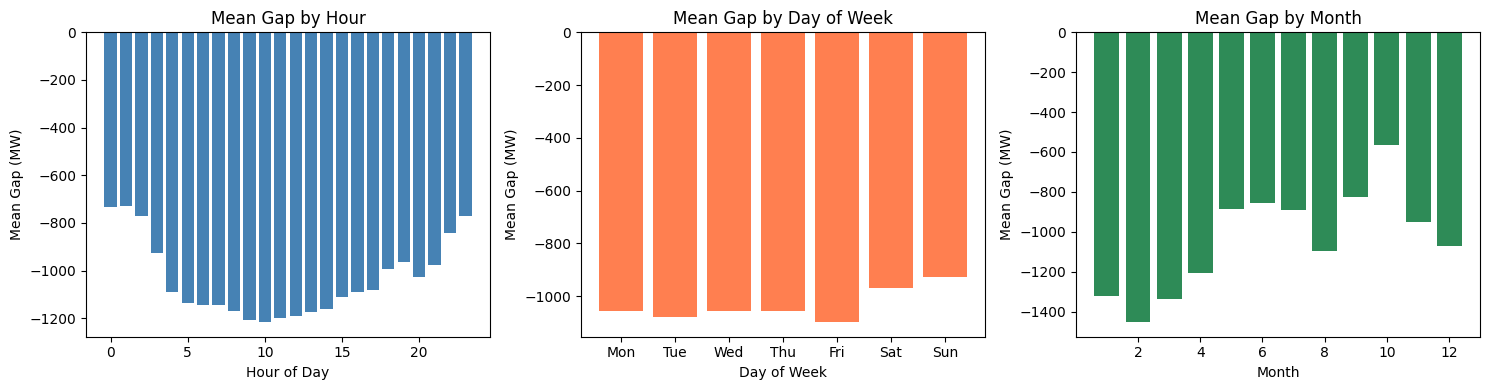

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hourly_gap = df.groupby('hour')['Gap'].mean()
axes[0].bar(hourly_gap.index, hourly_gap.values, color='steelblue')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Gap (MW)')
axes[0].set_title('Mean Gap by Hour')
axes[0].axhline(0, color='black', linestyle='-', linewidth=0.5)

dow_gap = df.groupby('dow')['Gap'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(dow_labels, dow_gap.values, color='coral')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Gap (MW)')
axes[1].set_title('Mean Gap by Day of Week')
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)

monthly_gap = df.groupby('month')['Gap'].mean()
axes[2].bar(monthly_gap.index, monthly_gap.values, color='seagreen')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Mean Gap (MW)')
axes[2].set_title('Mean Gap by Month')
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gap_by_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Training

In [14]:
target_cols = [f'Gap_t_plus_{h}h' for h in range(1, 13)]
feature_cols = [c for c in df.columns if c not in target_cols + ['Gap'] and not c.startswith('Gap_t_plus')]

print(f"Features: {len(feature_cols)}")
print(f"Targets: {len(target_cols)}")

Features: 110
Targets: 12


In [15]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

RESEARCH = True
if RESEARCH:
    TEST_SIZE = 30 * 24 
    tscv = TimeSeriesSplit(n_splits=5, test_size=TEST_SIZE)

    # base = HistGradientBoostingRegressor(
    #     learning_rate=0.05,
    #     max_depth=8,
    #     max_iter=500,
    #     random_state=42
    # )

    base = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    )

    model = MultiOutputRegressor(base)

    X = df[feature_cols]
    Y = df[target_cols]

    rows = []
    all_predictions = {}
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        print(f"Fold {fold}: Train indices {train_idx[0]}-{train_idx[-1]}, Test indices {test_idx[0]}-{test_idx[-1]}")
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]

        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test) 

        # Evaluate each horizon separately
        for j, h in enumerate(target_cols):
            y_true_h = Y_test.iloc[:, j].values
            y_pred_h = Y_pred[:, j]
            
            if fold == 5:
                all_predictions[h] = pd.DataFrame({
                    "datetime": Y_test.index,
                    "actual": y_true_h,
                    "predicted": y_pred_h
                })

            rows.append({
                "fold": fold,
                "horizon_h": h,
                "MAE": mean_absolute_error(y_true_h, y_pred_h),
                "RMSE": rmse(y_true_h, y_pred_h),
                "R2": r2_score(y_true_h, y_pred_h)
            })

    results = pd.DataFrame(rows)

    print("Per-horizon mean across folds:")
    display(
        results.groupby("horizon_h")[["MAE","RMSE","R2"]].mean()
        .style
        .background_gradient(subset=["MAE","RMSE"], cmap="Reds_r", axis=0)
        .background_gradient(subset=["R2"], cmap="Greens", axis=0)    
    )

    print("\nOverall mean (all horizons & folds):")
    print(results[["MAE","RMSE","R2"]].mean())

Fold 1: Train indices 0-48816, Test indices 48817-49536
Fold 2: Train indices 0-49536, Test indices 49537-50256
Fold 3: Train indices 0-50256, Test indices 50257-50976
Fold 4: Train indices 0-50976, Test indices 50977-51696
Fold 5: Train indices 0-51696, Test indices 51697-52416
Per-horizon mean across folds:


,MAE,RMSE,R2
horizon_h,,,
Gap_t_plus_10h,639.452883,798.374233,0.363232
Gap_t_plus_11h,662.966174,829.507652,0.313487
Gap_t_plus_12h,687.343291,857.927225,0.259120
Gap_t_plus_1h,201.739111,259.923536,0.933758
Gap_t_plus_2h,274.959550,357.389081,0.876138
Gap_t_plus_3h,342.327259,441.139123,0.810334
Gap_t_plus_4h,388.481647,502.794816,0.752749
Gap_t_plus_5h,432.476887,561.555450,0.691571
Gap_t_plus_6h,471.818815,610.582646,0.637603



Overall mean (all horizons & folds):
MAE     481.927334
RMSE    613.328913
R2        0.593863
dtype: float64


In [16]:
results_df = pd.DataFrame(results)
print("\nModel Performance Summary:")
print(results_df.to_string(index=False))


Model Performance Summary:
 fold      horizon_h        MAE       RMSE       R2
    1  Gap_t_plus_1h 214.744288 279.571368 0.921745
    1  Gap_t_plus_2h 304.725412 399.764065 0.839633
    1  Gap_t_plus_3h 386.585446 500.730677 0.747943
    1  Gap_t_plus_4h 447.955496 576.341600 0.664643
    1  Gap_t_plus_5h 508.974149 651.686899 0.569186
    1  Gap_t_plus_6h 542.674782 689.080575 0.515141
    1  Gap_t_plus_7h 572.695475 733.766642 0.445805
    1  Gap_t_plus_8h 613.088316 784.918830 0.360779
    1  Gap_t_plus_9h 655.064290 825.975610 0.287421
    1 Gap_t_plus_10h 667.070430 839.591375 0.259738
    1 Gap_t_plus_11h 683.680602 861.214267 0.216421
    1 Gap_t_plus_12h 717.982651 904.717231 0.130754
    2  Gap_t_plus_1h 202.299475 264.169035 0.945729
    2  Gap_t_plus_2h 282.307157 381.014230 0.887322
    2  Gap_t_plus_3h 348.521532 467.839676 0.830183
    2  Gap_t_plus_4h 393.776961 530.649117 0.781801
    2  Gap_t_plus_5h 439.457378 598.520369 0.722819
    2  Gap_t_plus_6h 478.092450 660.

## 6. Prediction Distribution Analysis

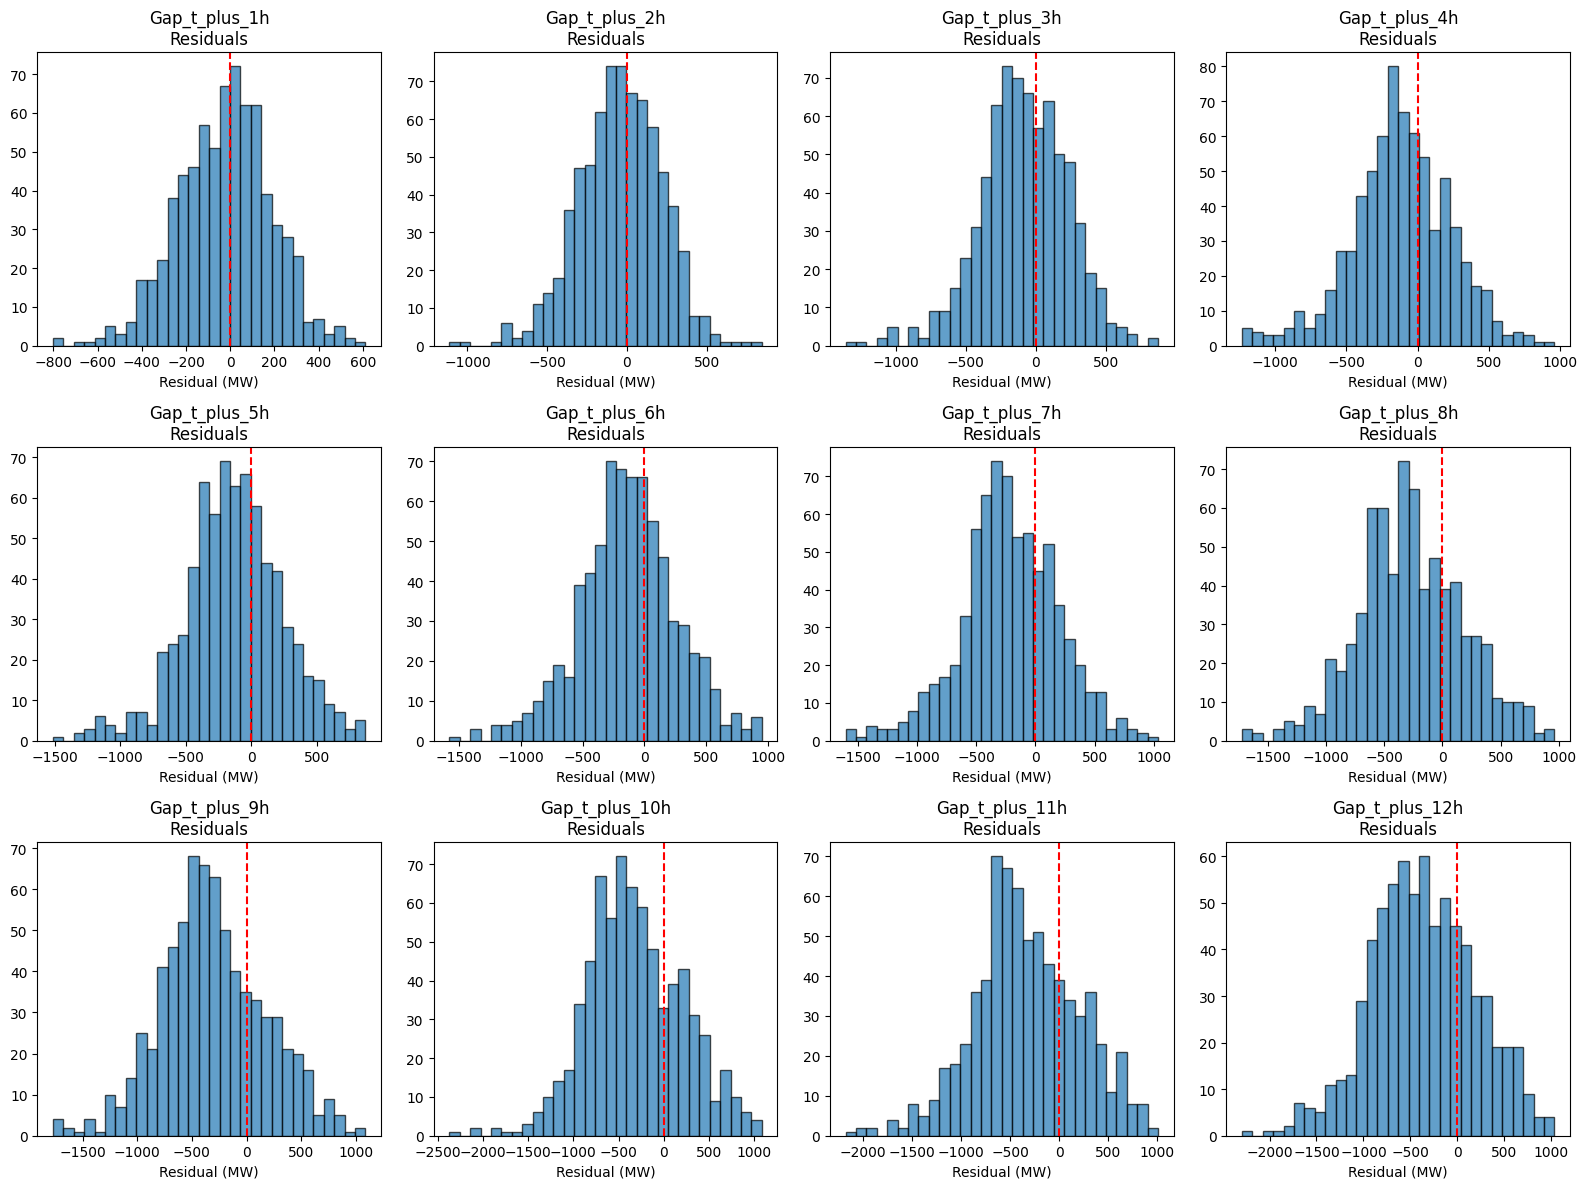

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(target_cols):
    pred_df = all_predictions[target]
    residuals = pred_df['actual'] - pred_df['predicted']
    
    axes[idx].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'{target}\nResiduals')
    axes[idx].set_xlabel('Residual (MW)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residuals_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

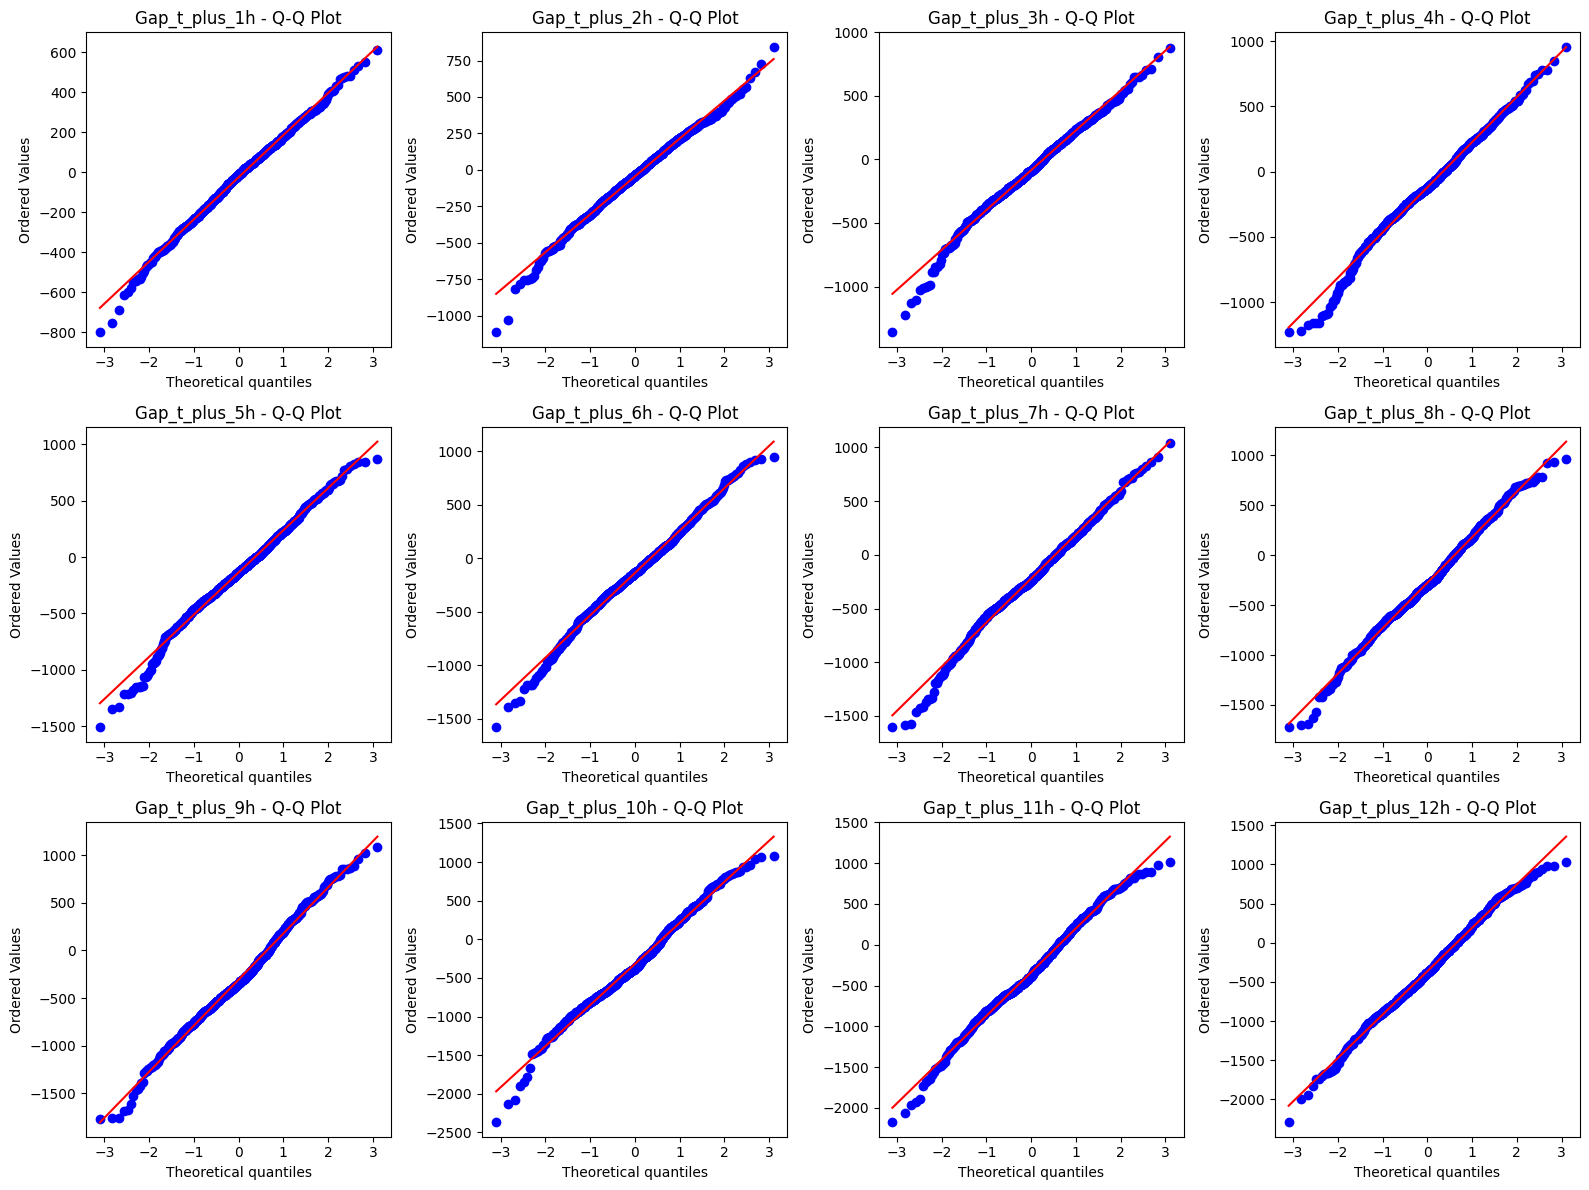

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(target_cols):
    pred_df = all_predictions[target]
    
    stats.probplot(pred_df['actual'] - pred_df['predicted'], dist="norm", plot=axes[idx])
    axes[idx].set_title(f'{target} - Q-Q Plot')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'qq_plots_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

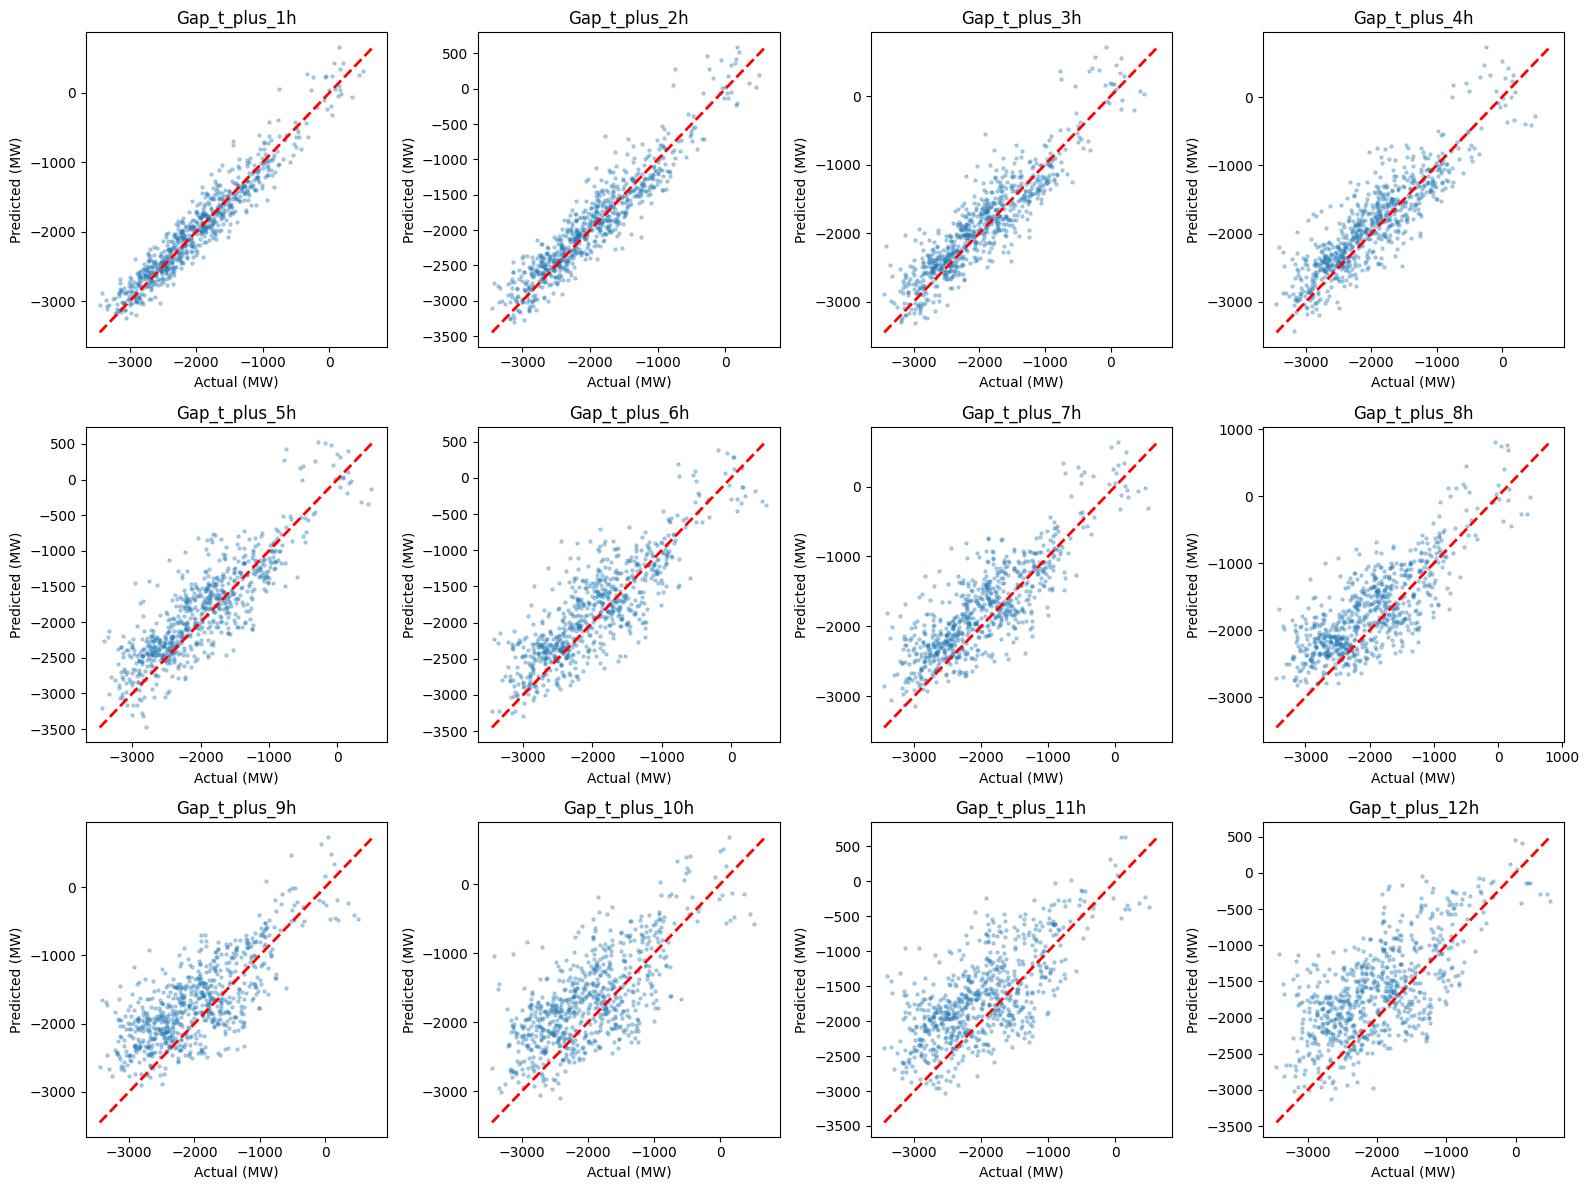

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(target_cols):
    pred_df = all_predictions[target]
    
    axes[idx].scatter(pred_df['actual'], pred_df['predicted'], alpha=0.3, s=5)
    min_val = min(pred_df['actual'].min(), pred_df['predicted'].min())
    max_val = max(pred_df['actual'].max(), pred_df['predicted'].max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[idx].set_xlabel('Actual (MW)')
    axes[idx].set_ylabel('Predicted (MW)')
    axes[idx].set_title(f'{target}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Inference

In [20]:
# Split last 7 days as final test set (unseen during training)
date_range = pd.date_range('2026-02-08', '2026-02-16', freq='H', tz='UTC')
test_set = df[df.index.isin(date_range)]

train_set = df[~df.index.isin(date_range)]
train_set.to_parquet("fin_train_set.parquet", index=True)

test_set[feature_cols].to_parquet("fin_x_test_set.parquet", index=True)
test_set[target_cols].to_parquet("fin_y_test_set.parquet", index=True)

# Fit xgboost on train set
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)
X_train = train_set[feature_cols]
Y_train = train_set[target_cols]

model.fit(X_train, Y_train)

joblib.dump(model, "fin_model.joblib")


# Predict on test set
X_test = test_set[feature_cols]
Y_test = test_set[target_cols]
Y_pred = model.predict(X_test)

# Evaluate
test_results = []
for j, h in enumerate(target_cols):
    y_true_h = Y_test.iloc[:, j].values
    y_pred_h = Y_pred[:, j]

    test_results.append({
        "horizon_h": h,
        "MAE": mean_absolute_error(y_true_h, y_pred_h),
        "RMSE": rmse(y_true_h, y_pred_h),
        "R2": r2_score(y_true_h, y_pred_h)
    })
test_results_df = pd.DataFrame(test_results)
display(
    test_results_df
    .style
    .background_gradient(subset=["MAE","RMSE"], cmap="Reds_r", axis=0)
    .background_gradient(subset=["R2"], cmap="Greens", axis=0)
)

,horizon_h,MAE,RMSE,R2
0,Gap_t_plus_1h,157.469221,199.821258,0.834602
1,Gap_t_plus_2h,184.076456,233.528710,0.771299
2,Gap_t_plus_3h,224.479121,276.323521,0.676581
3,Gap_t_plus_4h,254.992292,313.366745,0.584171
4,Gap_t_plus_5h,287.442841,348.487672,0.482033
5,Gap_t_plus_6h,324.501174,390.865847,0.343267
6,Gap_t_plus_7h,313.633850,393.823574,0.323284
7,Gap_t_plus_8h,331.870114,423.155066,0.206552
8,Gap_t_plus_9h,355.209259,443.299136,0.121352
9,Gap_t_plus_10h,390.852434,483.867369,-0.055778


## 8. Exports

In [21]:
results_df.to_csv(OUTPUT_DIR / 'metrics.csv', index=False)
print(f"Exported: {OUTPUT_DIR / 'metrics.csv'}")

predictions_combined = pd.concat(all_predictions, names=['horizon']).reset_index()
predictions_combined.to_csv(OUTPUT_DIR / 'predictions.csv', index=False)
print(f"Exported: {OUTPUT_DIR / 'predictions.csv'}")

Exported: /Users/armandhubler/Documents/coding_project/hackeurope26/ml/fin/metrics.csv
Exported: /Users/armandhubler/Documents/coding_project/hackeurope26/ml/fin/predictions.csv


## 8. Sample Day Visualization

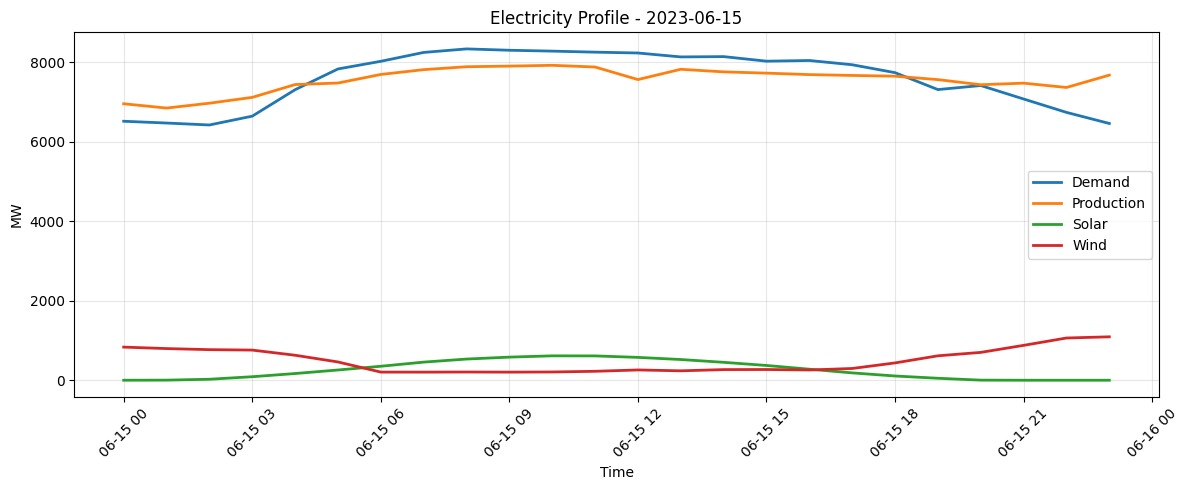

In [22]:
sample_date = '2023-06-15'
day_data = df[df.index.date == pd.to_datetime(sample_date).date()]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(day_data.index, day_data['demand'], label='Demand', linewidth=2)
ax.plot(day_data.index, day_data['overall_production'], label='Production', linewidth=2)
ax.plot(day_data.index, day_data['solar_production'], label='Solar', linewidth=2)
ax.plot(day_data.index, day_data['wind_production'], label='Wind', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('MW')
ax.set_title(f'Electricity Profile - {sample_date}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_day.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [23]:
print("="*50)
print("MODEL SUMMARY")
print("="*50)
print(f"Dataset: Finland Electricity")
print(f"Total samples: {len(df)}")
print(f"Features: {len(feature_cols)}")
print(f"Target: Gap (production - demand)")
print(f"Horizons: 1-12 hours")
print(f"\nTarget statistics:")
print(f"  Mean Gap: {df['Gap'].mean():.2f} MW")
print(f"  Std Gap: {df['Gap'].std():.2f} MW")
print(f"  Min Gap: {df['Gap'].min():.2f} MW")
print(f"  Max Gap: {df['Gap'].max():.2f} MW")
print(f"\nInterpretation:")
print(f"  Negative gap = demand exceeds production (importing)")
print(f"  Positive gap = production exceeds demand (exporting)")

MODEL SUMMARY
Dataset: Finland Electricity
Total samples: 52417
Features: 110
Target: Gap (production - demand)
Horizons: 1-12 hours

Target statistics:
  Mean Gap: -1035.32 MW
  Std Gap: 1155.77 MW
  Min Gap: -4619.00 MW
  Max Gap: 3395.55 MW

Interpretation:
  Negative gap = demand exceeds production (importing)
  Positive gap = production exceeds demand (exporting)
